___

<a href='http://www.pieriandata.com'><img src='../Pierian_Data_Logo.png'/></a>
___
<center><em>Авторские права принадлежат Pierian Data Inc.</em></center>
<center><em>Для дополнительной информации посетите наш сайт <a href='http://www.pieriandata.com'>www.pieriandata.com</a></em></center>

# Проверочные задания по классификации текста

### На входе у Вас будет набор текстовых отзывов о фильмах, размеченных как положительные и отрицательные (позитивные и негативные).

Более подробно об этих данных можно почитать здесь: http://ai.stanford.edu/~amaas/data/sentiment/

## Выполните задания, написанные жирным шрифтом!

**Задание: Выполните импорт библиотек и загрузите данные из файла в датафрейм pandas.** <br>
Данные для этого задания находятся в файле `'../DATA/moviereviews.csv'`.

In [225]:
# Напишите Ваш код в этой ячейке
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [226]:
df = pd.read_csv('../DATA/moviereviews.csv')

In [227]:
df.head()

,label,review
0,neg,how do films like mouse hunt get into theatres...
1,neg,some talented actresses are blessed with a dem...
2,pos,this has been an extraordinary year for austra...
3,pos,according to hollywood movies made in last few...
4,neg,my first press screening of 1998 and already i...


**Задание: Проверьте, есть ли какие-либо отсутствующие значения в этих данных.**

In [228]:
# Напишите Ваш код в этой ячейке
df.isna().sum()

label      0
review    35
dtype: int64

**Задание: Удалите отзывы о фильмах, текст которых принимает значение NaN**

In [229]:
df = df.dropna(subset=['review'])

**Задание: Проверьте, есть ли какие-то отзывы с пустым текстом, но отличающимся от значения NaN. То есть, текст может быть таким: "" или "  " или какая-то другая строка из нескольких пробелов. Как это можно проверить? Это можно сделать разными способами. После того как Вы найдёте такие отзывы, удалите их из датафрейма. [В качестве подсказки можете использовать эту ссылку.](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.isspace.html)**

In [230]:
df['review'].str.isspace().sum()

27

In [231]:
df[df['review'].str.isspace()]

,label,review
57,neg,
71,pos,
147,pos,
151,pos,
283,pos,
307,pos,
313,neg,
323,pos,
343,pos,
351,neg,


In [232]:
df = df[~df['review'].str.isspace()]

In [233]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1938 entries, 0 to 1999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   1938 non-null   object
 1   review  1938 non-null   object
dtypes: object(2)
memory usage: 45.4+ KB


**Задание: Посчитайте количество строк для различных значений колонки label:**

In [234]:
# Напишите Ваш код в этой ячейке
df['label'].value_counts()

label
neg    969
pos    969
Name: count, dtype: int64

## Исследование данных (EDA) для мешка слов (bag of words)

**Бонусное задание: можете ли Вы с помощью модели CountVectorizer найти 20 наиболее часто встречающихся слов (которые не являются стоп-словами в английском языке), отдельно для каждого значения колонки label? Обратите внимание, что это бонусное задание, и здесь Вам нужно будет сделать нечто такое, что мы не проходили в лекциях. Однако мы надеемся, что с помощью поиска в Google или другом поисковике Вы сможете найти недостающие элементы.  [В качестве подсказки можете использовать эту ссылку.](https://stackoverflow.com/questions/16288497/find-the-most-common-term-in-scikit-learn-classifier)**

In [235]:
from sklearn.feature_extraction.text import CountVectorizer

In [236]:
cvec = CountVectorizer(stop_words='english')

In [237]:
cvec.fit(df[df['label'] == 'neg']['review'])

CountVectorizer(stop_words='english')

In [238]:
matrix = cvec.transform(df[df['label'] == 'neg']['review'])

In [239]:
cvec.get_feature_names_out()

array(['00', '000', '007', ..., 'zwick', 'zwigoff', 'zzzzzzz'],
      dtype=object)

In [240]:
pd.Series(matrix.toarray().sum(axis=0), cvec.get_feature_names_out()).sort_values(ascending=False)[:20]

film          4063
movie         3131
like          1808
just          1480
time          1127
good          1117
bad            997
character      926
story          908
plot           888
characters     838
make           813
really         743
way            734
little         696
don            683
does           666
doesn          648
action         635
scene          634
dtype: int64

In [241]:
matrix = cvec.fit_transform(df[df['label'] == 'pos']['review'])

In [242]:
pd.Series(matrix.toarray().sum(axis=0), cvec.get_feature_names_out()).sort_values(ascending=False)[:20]

film          5002
movie         2389
like          1721
just          1273
story         1199
good          1193
time          1175
character     1037
life          1032
characters     957
way            864
films          851
does           828
best           788
people         769
make           764
little         751
really         731
man            728
new            702
dtype: int64

### Данные и обучение модели

**Задание: Разделите данные на признаки X и целевую переменную y, а также выполните разбиение на обучающий и тестовый наборы данных (train/test split). Вы можете использовать любые значения параметров, но если Вы захотите свериться с блокнотом с решениями, то в нём мы использовали `test_size=0.20, random_state=101`**

In [243]:
# Напишите Ваш код в этой ячейке
X = df['review']
y = df['label']

In [244]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

### Обучение модели

**Задание: Создайте пайплайн, в котором Вы создадите вектора TF-IDF из сырых текстовых даных, а затем обучите модель машинного обучения, которую сами выберете. После создания пайплайна выполните его обучение на обучающем наборе данных.**

In [245]:
# Напишите Ваш код в этой ячейке
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

In [246]:
pipe = Pipeline([('tdidf', TfidfVectorizer(stop_words='english')),
                  ('svc', LinearSVC())])

In [247]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('tdidf', TfidfVectorizer(stop_words='english')),
                ('svc', LinearSVC())])

**Задание: выведите на экран отчёт "classification report" и матрицу ошибок для результатов работы пайплайна на тестовых данных.**

In [248]:
# Напишите Ваш код в этой ячейке

In [249]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [250]:
def model_report(model):
    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

    disp.plot();

              precision    recall  f1-score   support

         neg       0.81      0.84      0.82       191
         pos       0.84      0.81      0.82       197

    accuracy                           0.82       388
   macro avg       0.82      0.82      0.82       388
weighted avg       0.83      0.82      0.82       388



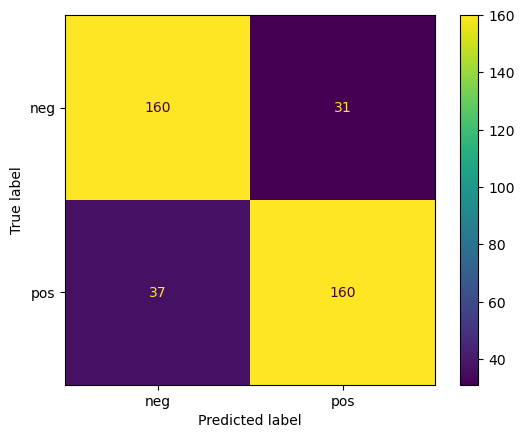

In [251]:
model_report(pipe)

In [252]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [253]:
rf = RandomForestClassifier()

In [254]:
params = {'n_estimators': np.arange(80, 121, 20),
          'criterion': ['gini', 'entropy'],
          'max_depth': np.arange(3, 10),
          'min_samples_split': np.arange(2, 4)}

In [255]:
gs = GridSearchCV(estimator=rf, param_grid=params, cv=5, n_jobs=-1)

In [256]:
pipe_rf = Pipeline([('tdidf', TfidfVectorizer(stop_words='english')),
                    ('model', gs)])

In [257]:
pipe_rf.fit(X_train, y_train)

Pipeline(steps=[('tdidf', TfidfVectorizer(stop_words='english')),
                ('model',
                 GridSearchCV(cv=5, estimator=RandomForestClassifier(),
                              n_jobs=-1,
                              param_grid={'criterion': ['gini', 'entropy'],
                                          'max_depth': array([3, 4, 5, 6, 7, 8, 9]),
                                          'min_samples_split': array([2, 3]),
                                          'n_estimators': array([ 80, 100, 120])}))])

              precision    recall  f1-score   support

         neg       0.76      0.85      0.80       191
         pos       0.84      0.75      0.79       197

    accuracy                           0.80       388
   macro avg       0.80      0.80      0.80       388
weighted avg       0.80      0.80      0.80       388



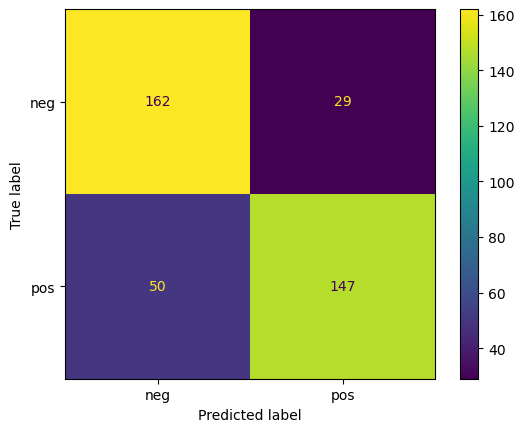

In [258]:
model_report(pipe_rf)

## Отличная работа!

In [286]:
from sklearn.linear_model import RidgeClassifier, LogisticRegression
from sklearn.svm import LinearSVC, SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier

In [327]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [328]:
models = [RidgeClassifier(), LogisticRegression(), LinearSVC(), SVC(), RandomForestClassifier(), AdaBoostClassifier(), GradientBoostingClassifier()]

In [348]:
def get_metrics(model):
    
    results_list = []
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    name = model.steps[1][1].__class__.__name__
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label='pos')
    rec = recall_score(y_test, y_pred, pos_label='pos')
    f1 = f1_score(y_test, y_pred, pos_label='pos')

    if hasattr(model.steps[1][1], 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)
    roc_auc = roc_auc_score(y_test, y_proba)

    print(f'Model: {name:30} Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}, RocAuc: {roc_auc:.4f}')

In [349]:
for model in models:
    pipe = Pipeline([('tdidf', TfidfVectorizer(stop_words='english')),
                    ('model', model)])
    get_metrics(pipe)

Model: RidgeClassifier                Acc: 0.8247, Prec: 0.8342, Rec: 0.8173, F1: 0.8256, RocAuc: 0.9102
Model: LogisticRegression             Acc: 0.8222, Prec: 0.8478, Rec: 0.7919, F1: 0.8189, RocAuc: 0.9013
Model: LinearSVC                      Acc: 0.8247, Prec: 0.8377, Rec: 0.8122, F1: 0.8247, RocAuc: 0.9111
Model: SVC                            Acc: 0.8273, Prec: 0.8421, Rec: 0.8122, F1: 0.8269, RocAuc: 0.8954
Model: RandomForestClassifier         Acc: 0.7758, Prec: 0.8354, Rec: 0.6954, F1: 0.7590, RocAuc: 0.8697
Model: AdaBoostClassifier             Acc: 0.7294, Prec: 0.7771, Rec: 0.6548, F1: 0.7107, RocAuc: 0.8184
Model: GradientBoostingClassifier     Acc: 0.7887, Prec: 0.8108, Rec: 0.7614, F1: 0.7853, RocAuc: 0.8569
